# **Update data 5G Main KPI CSON**

I used this code to update my database in PostgreSQL for Daily 5G KPI Performance

In [20]:
# Import required library

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

from datetime import datetime, timedelta, date
from sqlalchemy import create_engine

### **1. Open and Append Data File(s)**

In [21]:
# 1. Define the path to your Downloads folder
path = os.path.expanduser("~/Downloads/")

# 2. Define the pattern to search for
search_pattern = os.path.join(path, "*5G Main KPI*.csv")  # The '*' means "anything before or after this text"

# 3. List all matching files
target_files = glob.glob(search_pattern)

# 4. Combine the data from all files into a single DataFrame
df_list = []

for file in target_files:
    temp_df = pd.read_csv(file)  # Read each file, specifying data types for certain columns
    # temp_df['source_file'] = os.path.basename(file)                   # Optional: Add a column to track which date the data came from
    df_list.append(temp_df)                                             # Append data
    
# Transform: Combine all 4G files into one
df = pd.concat(df_list, ignore_index=True)

### **2. Extracting and Transform Data File(s)**

In [22]:
# Rename columns to make easier to work with
df.rename(columns={"DATETIME" : "DATE"}, inplace=True)

# Convert DATE column to datetime format to YYYY-MM-DD
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%y', errors='coerce')

# df["DATE"] = pd.to_datetime(df["DATE"])
# df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True, errors='coerce')
# df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce').dt.date
# df['DATE'] = df['DATE'].dt.strftime('%Y-%m-%d')

# Sort Columns
df = df[['DATE',
         'REGION',
         'DISTRICT',
         'SITENAME',
         'CELL',
         'CI',
         'NRARFCN',
         'Collection_Interval',
         'nr_sn_setup_success_rate',
         'nr_retainability_rate',
         'nr_inter_handover_success_rate',
         'nr_intra_handover_success_rate',
         'nr_prb_utilization_dl_rate',
         'nr_prb_utilization_ul_rate',
         'nr_cell_throughput_dl_mbps_relactuserdl',
         'nr_cell_throughput_ul_mbps_relactuserdl',
         'nr_user_throughput_dl_mbps_relactuserdl',
         'nr_user_throughput_ul_mbps_relactuserdl',
         'nr_dl_active_user_avg',
         'nr_ul_active_user_avg',
         'nr_rrc_user_number',
         'nr_active_user_number',
         'nr_dl_payload_volume_gbyte',
         'nr_ul_payload_volume_gbyte',
         'nr_payload_volume_gbyte',
         'nr_availability_rate',
         'nr_latency_dl_ms',
         'nr_packet_loss_rate']]

# Sort the DataFrame by multiple columns in ascending order
df = df.sort_values(
    by=['DATE', 'REGION', 'DISTRICT', 'SITENAME', 'CELL'], 
    ascending=True
)

In [23]:
# 1. Define columns to be transformed
payload_cols = [
    'nr_dl_payload_volume_gbyte',
    'nr_ul_payload_volume_gbyte',
    'nr_payload_volume_gbyte'
]

# 2. Define the lists
exclude_regions = ["BALI NUSRA", "CENTRAL JAVA", "EAST JAVA"]
exclude_districts = ["PENAJAM PASER UTARA", "KOTA SAMARINDA", "KOTA BALIKPAPAN", "KOTA TARAKAN"]

# 3. Build the mask with proper parentheses
# Logic: (Not in Java/Bali) AND (If it is Kalimantan, then it must not be in the City list)
mask = (
    (~df['REGION'].isin(exclude_regions)) & 
    (
        (df['REGION'] != "KALIMANTAN") | 
        (~df['DISTRICT'].isin(exclude_districts))
    )
)

# 4. Apply the division
df.loc[mask, payload_cols] = df.loc[mask, payload_cols] / 1024

print(f"Successfully adjusted {mask.sum()} rows.")

Successfully adjusted 1366 rows.


In [24]:
# Convert some columns to integer, but first convert to numeric and coerce errors to NaN, then convert to Int64 which allows for NA values
int_columns = [
    'CI',
    'NRARFCN',
    'Collection_Interval'
]

# 2. Loop through the list and apply the conversion
for col in int_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

### **3. Connect to PostgreSQL Engine**

In [25]:
########################################################################################
# WARNING: Make sure the values ​​below are not published publicly or uploaded to the repository,
# because this is sensitive information that could be used to access our database.
# For larger projects, it's best to use environment variables or configuration files that aren't uploaded to the repository to store this information.
########################################################################################

DB_USER = "postgres"
DB_PASS = "12345"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "postgres"

In [26]:
# Create engine to connect to PostgreSQL database using SQLAlchemy

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

### **4. Append Data to existing database**

In [27]:
# Function to use PostgreSQL's COPY command for faster bulk inserts

import csv
from io import StringIO

def psql_insert_copy(table, conn, keys, data_iter):
    # gets a DBAPI connection from the sqlalchemy engine
    dbapi_conn = conn.connection
    with dbapi_conn.cursor() as cur:
        s_buf = StringIO()
        writer = csv.writer(s_buf)
        writer.writerows(data_iter)
        s_buf.seek(0)

        columns = ', '.join('"{}"'.format(k) for k in keys)
        if table.schema:
            table_name = '{}.{}'.format(table.schema, table.name)
        else:
            table_name = table.name

        sql = 'COPY "{}" ({}) FROM STDIN WITH CSV'.format(table_name, columns) # Add double quotes around table name to handle special characters or reserved keywords
        cur.copy_expert(sql=sql, file=s_buf)

In [28]:
# Import data to a table in the PostgreSQL database using the to_sql method from pandas and chunking to avoid memory issues

# 1. Define your chunk size (100k rows is usually safe for 16GB RAM)
chunk_size = 100000

# 2. Loop through the dataframe in pieces
for i in range(0, len(df), chunk_size):
    # Select the current chunk
    df_chunk = df.iloc[i : i + chunk_size]
    
    # Upload this chunk using the fast COPY method
    df_chunk.to_sql(
        name="5G_CSON_KPI_202603", 
        con=engine, 
        if_exists="append", 
        index=False, 
        method=psql_insert_copy
    )
    
    print(f"Successfully uploaded rows {i} to {min(i + chunk_size, len(df))}")

print("--- All Data Uploaded Successfully ---")

Successfully uploaded rows 0 to 4587
--- All Data Uploaded Successfully ---


### **5. Data verification using line chart from PostgreSQL**

##### **5.1 Create SQL Query**

In [29]:
# SQL Query to get the count of records per date
query = """
SELECT "DATE", COUNT(*) as "Num of Records" 
FROM "5G_CSON_KPI_202603" 
GROUP BY "DATE" 
ORDER BY "DATE" ASC
"""

In [30]:
# Load the query into a DataFrame
df_counts = pd.read_sql(query, engine)

##### **5.2 Create line chart**

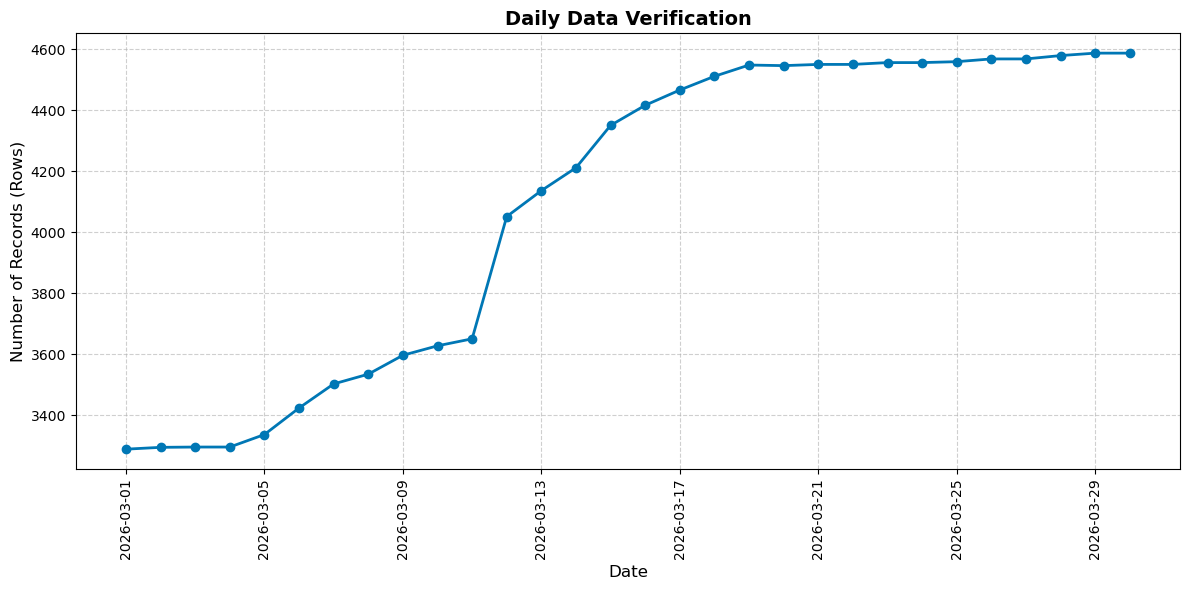

In [31]:
# Create the Line Chart
plt.figure(figsize=(12, 6))
plt.plot(df_counts['DATE'], df_counts['Num of Records'], marker='o', color='#0077B5', linewidth=2)

# Styling
plt.title('Daily Data Verification', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Records (Rows)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=90)
plt.tight_layout()
# plt.ylim(bottom=0)

# Display/Save
plt.show()